In [57]:
"""
Created on Fri Aug 15 2025

@author: vanln@ntnu.no
"""

'\nCreated on Fri Aug 15 2025\n\n@author: vanln@ntnu.no\n'

# **Run several Machine Learning regession models to assess the condition of the drainage pipeline system in the city of Ålesund, Norway**

# Machine Learning Models used:
####    1. Gaussian Process Regression
####    2. K-Nearest Neighbour (KNN)
####    3. Decision Tree
####    4. Random Forest
####    5. Support Vector Machine (SVM)
####    6. Multi-layer Perceptron

### **Set up environment**

### *- Create a python environment (in VSCodes)*
#### python -m venv <environment_name>
### *- Install packages in 'requirements.txt'*
#### pip install -r requirements.txt

## Import libraries

In [58]:
import pickle
import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RationalQuadratic
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

## Read data

In [59]:
train_path = 'Train_Data.csv'
test_path = 'Test_Data.csv'
data_train = pd.read_csv(train_path)
data_test = pd.read_csv(test_path)

In [60]:
data_train.head()

,PipeID,Age,Diameter,Depth,Slope,Length,Pipe_type,Connection,Pipe_form,Material,...,Geology,GroundWater Level,Soil_type,Landslide_area,Population,Building_area,Land_cover,Distance_to_road,TrafficVol,Score
0,165719,1,200,-0.17,-0.97,38.28,Stormwater,Others,S,PVC,...,Geology-3,6.19,SoilType-6,No,81,No,LandCover-1,RoadClass-2,0,91
1,159672,1,160,-0.20,0.62,41.17,Wastewater,Others,S,PVC,...,Geology-2,2.60,SoilType-9,No,24,No,LandCover-2,RoadClass-3,0,0
2,63977,1,250,-0.26,5.26,36.94,Stormwater,MUF,S,Others,...,Geology-2,20.65,SoilType-6,No,75,No,LandCover-3,RoadClass-2,0,8
3,63992,1,200,-0.45,2.39,28.36,Stormwater,MUF,S,Others,...,Geology-2,20.63,SoilType-6,No,75,No,LandCover-3,RoadClass-3,0,0
4,159670,1,160,-0.62,0.71,29.42,Wastewater,Others,S,PVC,...,Geology-0,2.90,SoilType-9,No,24,No,LandCover-2,RoadClass-3,0,0


## Process data

In [61]:
# Remove unnecessary columns
column_drop = ['PipeID']
data_train_new = data_train.drop(columns=column_drop)
data_test_new = data_test.drop(columns=column_drop)
data_train_new.head()

,Age,Diameter,Depth,Slope,Length,Pipe_type,Connection,Pipe_form,Material,Rainfall,Geology,GroundWater Level,Soil_type,Landslide_area,Population,Building_area,Land_cover,Distance_to_road,TrafficVol,Score
0,1,200,-0.17,-0.97,38.28,Stormwater,Others,S,PVC,139.95,Geology-3,6.19,SoilType-6,No,81,No,LandCover-1,RoadClass-2,0,91
1,1,160,-0.20,0.62,41.17,Wastewater,Others,S,PVC,149.57,Geology-2,2.60,SoilType-9,No,24,No,LandCover-2,RoadClass-3,0,0
2,1,250,-0.26,5.26,36.94,Stormwater,MUF,S,Others,131.85,Geology-2,20.65,SoilType-6,No,75,No,LandCover-3,RoadClass-2,0,8
3,1,200,-0.45,2.39,28.36,Stormwater,MUF,S,Others,131.70,Geology-2,20.63,SoilType-6,No,75,No,LandCover-3,RoadClass-3,0,0
4,1,160,-0.62,0.71,29.42,Wastewater,Others,S,PVC,149.57,Geology-0,2.90,SoilType-9,No,24,No,LandCover-2,RoadClass-3,0,0


In [62]:
# Prepare data for training and testing
xtrain = data_train_new.drop(columns=['Score'])
y_train = data_train['Score']
xtest = data_test_new.drop(columns=['Score'])
y_test = data_test['Score']

In [63]:
# Convert character variable in the training dataset to numeric
ordinalEncoder = OrdinalEncoder()
lb_column = ['Pipe_type', 'Connection', 'Pipe_form', 'Material', 'Geology', 'Soil_type', 
              'Landslide_area', 'Building_area', 'Distance_to_road', 'Land_cover']
ordinalEncoder = OrdinalEncoder()
xtrain[lb_column] = ordinalEncoder.fit_transform(xtrain[lb_column])
xtest[lb_column] = ordinalEncoder.fit_transform(xtest[lb_column])
# Standardize data
scaler_x = MinMaxScaler(feature_range=(0, 1)).fit(xtrain)
scaler_y = MinMaxScaler(feature_range=(0, 1)).fit(np.array(y_train).reshape(-1, 1))
X_train = scaler_x.transform(xtrain)
X_test = scaler_x.transform(xtest)
y_scaler_train = scaler_y.transform(np.array(y_train).reshape(-1, 1))
y_scaler_test = scaler_y.transform(np.array(y_test).reshape(-1, 1))

## Machine Learning models Implementation

In [64]:
# Create a variable to store metrics of each model for comparison
metrics = {}

## 1. Gaussian Process Regression

In [49]:
# Initialize model using default parameters
# More details: https://scikit-learn.org/stable/modules/generated/sklearn.gaussian_process.GaussianProcessRegressor.html
GPR_model = GaussianProcessRegressor(kernel=RationalQuadratic(alpha=1, length_scale=1), random_state=42)
# Train model
GPR_result = GPR_model.fit(X_train, y_scaler_train)
# Evaluate model
y_pred, y_std = GPR_result.predict(X_test, return_std=True)
r2 = r2_score(y_scaler_test, y_pred)
mae = mean_absolute_error(y_scaler_test, y_pred)
rmse = float(np.sqrt(mean_squared_error(y_scaler_test, y_pred)))
# Print result
print('R2 score: %.2f' % r2)
print('Mean Absolute Error: %.2f' % mae)
print('Root Mean Squared Error: %.2f' % rmse)
# Store model metrics
metrics['Gaussian Process Regression'] = [r2, mae, rmse]
pd.DataFrame(data={'Actual': scaler_y.inverse_transform(y_scaler_test.reshape(-1, 1)).flatten(),
    'Predicted': np.round(scaler_y.inverse_transform(y_pred.reshape(-1, 1)).flatten(), 0), 'Std': y_std.flatten()})

R2 score: 0.89
Mean Absolute Error: 0.01
Root Mean Squared Error: 0.02


,Actual,Predicted,Std
0,0.0,0.0,0.000010
1,0.0,-0.0,0.000010
2,0.0,-0.0,0.000010
3,0.0,0.0,0.000010
4,1.0,30.0,0.082022
...,...,...,...
273,191.0,191.0,0.000010
274,319.0,223.0,0.079983
275,0.0,0.0,0.000010
276,165.0,165.0,0.000010


## 2. K-Nearest Neighbor (KNN)

In [50]:
# Initialize model using default parameters
# More details: https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html
KNN_model = KNeighborsRegressor(n_neighbors=90, algorithm='ball_tree', metric='manhattan', weights='uniform')
# Train model
KNN_result = KNN_model.fit(X_train, y_scaler_train)
# Evaluate model
y_pred = KNN_result.predict(X_test)
# Compute standard deviation
distances, indices = KNN_model.kneighbors(X_test)
neighbor_values = y_scaler_train[indices]
y_std = np.std(neighbor_values, axis=1)  # Standard deviation of neighbor values
# Compute metrics
r2 = r2_score(y_scaler_test, y_pred)
mae = mean_absolute_error(y_scaler_test, y_pred)
rmse = float(np.sqrt(mean_squared_error(y_scaler_test, y_pred)))
# Print result
print('R2 score: %.2f' % r2)
print('Mean Absolute Error: %.2f' % mae)
print('Root Mean Squared Error: %.2f' % rmse)
# Store model metrics
metrics['K-Nearest Neighbor'] = [r2, mae, rmse]
pd.DataFrame(data={'Actual': scaler_y.inverse_transform(y_scaler_test.reshape(-1, 1)).flatten(),
    'Predicted': np.round(scaler_y.inverse_transform(y_pred.reshape(-1, 1)).flatten(), 0), 'Std': y_std.flatten()})

R2 score: 0.21
Mean Absolute Error: 0.02
Root Mean Squared Error: 0.05


,Actual,Predicted,Std
0,0.0,19.0,0.044530
1,0.0,1.0,0.004021
2,0.0,4.0,0.007081
3,0.0,17.0,0.031295
4,1.0,4.0,0.006583
...,...,...,...
273,191.0,227.0,0.134510
274,319.0,168.0,0.092327
275,0.0,156.0,0.091494
276,165.0,162.0,0.086112


## 3. Decision Tree

In [51]:
# Initialize model using default parameters
# More details: https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html
DT_model = DecisionTreeRegressor(random_state=42, max_features=7, criterion='squared_error')
# Train model
DT_result = DT_model.fit(X_train, y_scaler_train)
# Evaluate model
y_pred = DT_result.predict(X_test)
# Compute standard deviation
leaf_indices = DT_result.apply(X_test)
y_std = []
for leaf_id in leaf_indices:
    idx_in_leaf = np.where(leaf_indices == leaf_id)[0]
    values_in_leaf = y_scaler_train[idx_in_leaf]
    std_dev = np.std(values_in_leaf)
    y_std.append(std_dev)
# Compute metrics
r2 = r2_score(y_scaler_test, y_pred)
mae = mean_absolute_error(y_scaler_test, y_pred)
rmse = float(np.sqrt(mean_squared_error(y_scaler_test, y_pred)))
# Print result
print('R2 score: %.2f' % r2)
print('Mean Absolute Error: %.2f' % mae)
print('Root Mean Squared Error: %.2f' % rmse)
# Store model metrics
metrics['Decision Tree'] = [r2, mae, rmse]
pd.DataFrame(data={'Actual': scaler_y.inverse_transform(y_scaler_test.reshape(-1, 1)).flatten(),
    'Predicted': np.round(scaler_y.inverse_transform(y_pred.reshape(-1, 1)).flatten(), 0), 'Std': y_std})

R2 score: -0.03
Mean Absolute Error: 0.01
Root Mean Squared Error: 0.05


,Actual,Predicted,Std
0,0.0,0.0,0.045972
1,0.0,0.0,0.000000
2,0.0,0.0,0.001333
3,0.0,0.0,0.000000
4,1.0,0.0,0.045972
...,...,...,...
273,191.0,191.0,0.000000
274,319.0,167.0,0.000000
275,0.0,0.0,0.000000
276,165.0,165.0,0.000000


## 4. Random Forest Regression

In [52]:
# Initialize model using default parameters
# More details: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html
RFR_model = RandomForestRegressor(random_state=42, n_estimators=96,max_features=2)
# Train model
RFR_result = RFR_model.fit(X_train, y_scaler_train.ravel())
# Evaluate model
y_pred = RFR_result.predict(X_test)
# Compute standard deviation
all_tree_preds = np.column_stack([est.predict(X_test) for est in RFR_result.estimators_])
y_std = all_tree_preds.std(axis=1, ddof=1)
# Compute metrics
r2 = r2_score(y_scaler_test, y_pred)
mae = mean_absolute_error(y_scaler_test, y_pred)
rmse = float(np.sqrt(mean_squared_error(y_scaler_test, y_pred)))
# Print result
print('R2 score: %.2f' % r2)
print('Mean Absolute Error: %.2f' % mae)
print('Root Mean Squared Error: %.2f' % rmse)
# Store model metrics
metrics['Random Forest Regression'] = [r2, mae, rmse]
pd.DataFrame(data={'Actual': scaler_y.inverse_transform(y_scaler_test.reshape(-1, 1)).flatten(),
    'Predicted': np.round(scaler_y.inverse_transform(y_pred.reshape(-1, 1)).flatten(), 0), 'Std': y_std})

R2 score: 0.79
Mean Absolute Error: 0.01
Root Mean Squared Error: 0.02


,Actual,Predicted,Std
0,0.0,3.0,0.003969
1,0.0,7.0,0.013227
2,0.0,1.0,0.004870
3,0.0,1.0,0.002057
4,1.0,2.0,0.004214
...,...,...,...
273,191.0,206.0,0.052103
274,319.0,215.0,0.074854
275,0.0,77.0,0.079913
276,165.0,186.0,0.047087


## 5. Support Vector Regression

In [53]:
# Initialize model using default parameters
# More details: https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVR.html
SVR_model = SVR(C=128, gamma=0.0009765625, kernel='rbf')
# Train model
SVR_result = SVR_model.fit(X_train, y_scaler_train.ravel())
# Evaluate model
y_pred = SVR_result.predict(X_test)
# Compute metrics
r2 = r2_score(y_scaler_test, y_pred)
mae = mean_absolute_error(y_scaler_test, y_pred)
rmse = float(np.sqrt(mean_squared_error(y_scaler_test, y_pred)))
# Print result
print('R2 score: %.2f' % r2)
print('Mean Absolute Error: %.2f' % mae)
print('Root Mean Squared Error: %.2f' % rmse)
# Store model metrics
metrics['Support Vector Regression'] = [r2, mae, rmse]
pd.DataFrame(data={'Actual': scaler_y.inverse_transform(y_scaler_test.reshape(-1, 1)).flatten(),
    'Predicted': np.round(scaler_y.inverse_transform(y_pred.reshape(-1, 1)).flatten(), 0)})

R2 score: -1.65
Mean Absolute Error: 0.08
Root Mean Squared Error: 0.09


,Actual,Predicted
0,0.0,222.0
1,0.0,193.0
2,0.0,203.0
3,0.0,218.0
4,1.0,204.0
...,...,...
273,191.0,276.0
274,319.0,258.0
275,0.0,254.0
276,165.0,264.0


## 6. Multilayer Perceptron

In [54]:
# Initialize model using default parameters
# More details: https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html
MLP_model = MLPRegressor(early_stopping=True, random_state=42, max_iter=5000,
                          activation='relu', hidden_layer_sizes=170, solver='lbfgs')
# Train model
MLP_result = MLP_model.fit(X_train, y_scaler_train.ravel())
# Evaluate model
y_pred = MLP_result.predict(X_test)
r2 = r2_score(y_scaler_test, y_pred)
mae = mean_absolute_error(y_scaler_test, y_pred)
rmse = float(np.sqrt(mean_squared_error(y_scaler_test, y_pred)))
# Print result
print('R2 score: %.2f' % r2)
print('Mean Absolute Error: %.2f' % mae)
print('Root Mean Squared Error: %.2f' % rmse)
# Store model metrics
metrics['Multilayer Perceptron'] = [r2, mae, rmse]
pd.DataFrame(data={'Actual': scaler_y.inverse_transform(y_scaler_test.reshape(-1, 1)).flatten(),
    'Predicted': np.round(scaler_y.inverse_transform(y_pred.reshape(-1, 1)).flatten(), 0)})

R2 score: 0.24
Mean Absolute Error: 0.02
Root Mean Squared Error: 0.05


,Actual,Predicted
0,0.0,-11.0
1,0.0,55.0
2,0.0,59.0
3,0.0,29.0
4,1.0,-188.0
...,...,...
273,191.0,193.0
274,319.0,159.0
275,0.0,73.0
276,165.0,184.0


<Axes: >

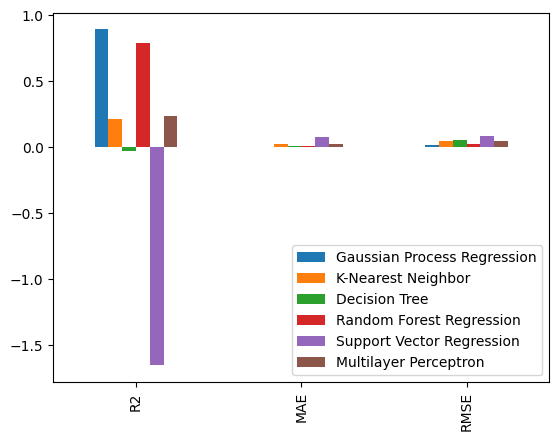

In [55]:
# Plot model metrics
df = pd.DataFrame(metrics, index=['R2', 'MAE', 'RMSE'])
df.plot.bar()

## Save model for future use

In [56]:
# Select model to predic
model = RFR_result
with open('model.pkl', 'wb') as file:
    pickle.dump(model, file)

# Data preparation for future data

In [65]:
# Read data used for prediction
new_data = pd.read_csv('2030_data.csv')
# Remove unnecessary columns
df_new = new_data.drop(columns=column_drop)
# Convert character variable in the training dataset to numeric
df_new[lb_column] = ordinalEncoder.fit_transform(df_new[lb_column])
# Standardize data
X_pred = scaler_x.transform(df_new)

# Prediction for future data

In [66]:
# # Load model
# with open('model.pkl', 'rb') as file:
#     model = pickle.load(file)
# Make prediction
y_pred = model.predict(X_pred)
# Compute standard deviation
all_tree_preds = np.column_stack([est.predict(X_pred) for est in model.estimators_])
y_std = all_tree_preds.std(axis=1, ddof=1)
# Print result
y_pred_rev = scaler_y.inverse_transform(y_pred.reshape(-1, 1)).flatten()
prediction = pd.DataFrame(data={'Predicted': y_pred_rev, 'Std': y_std})

In [68]:
prediction

,Predicted,Std
0,141.479167,0.155840
1,149.614583,0.171041
2,96.229167,0.071523
3,147.375000,0.169877
4,123.229167,0.087562
...,...,...
31288,119.895833,0.152720
31289,138.343750,0.139397
31290,115.208333,0.132851
31291,17.229167,0.020241


## Save prediction

In [67]:
prediction.to_csv('2030_prediction.csv', index=False)